In [66]:
## 1. Long-Short Strategy Framework
# Objective:
# In this notebook, I extend the conservative long-only framework into a long-short strategyusing the same trained classification model. 
# The goal is to test whether the model's predicted probabilities can support both long and short positioning, improve return capture, and maintain acceptable risk-adjusted performance relative to the long-only approach and SPY benchmark.

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from src.scoring import make_forward_returns

In [111]:
## 2. Set project paths Load preprocessed data
project_root = Path.cwd().parent
processed_data_path = project_root / "data" / "processed"
combined_features = pd.read_csv(processed_data_path / "notebook_03_features" / "combined_features.csv", index_col=0)
clean_close_prices = pd.read_csv(processed_data_path / "notebook_02_data_prep" / "clean_close_prices.csv", index_col=0)
ML_dataset = pd.read_csv(processed_data_path / "notebook_05_model_outputs" / "ML_dataset.csv", index_col=0)
ML_dataset.head()

,AAPL_ret,ABBV_ret,ACN_ret,ADBE_ret,AMZN_ret,AVGO_ret,BAC_ret,BRK-B_ret,COST_ret,CRM_ret,...,NVDA_lag5,PEP_lag5,PG_lag5,SPY_lag5,TMO_lag5,UNH_lag5,V_lag5,WMT_lag5,XOM_lag5,target
Date,,,,,,,,,,,,,,,,,,,,,
2018-03-29,0.007809,0.004031,0.041313,0.016656,0.011122,-0.004352,0.020415,0.014288,0.026251,0.030298,...,-0.026996,-0.007357,-0.008178,-0.024997,-0.026437,-0.034153,-0.026213,-0.011794,-0.020522,0
2018-04-02,-0.006556,-0.033703,-0.035961,-0.017586,-0.052061,-0.033822,-0.022674,-0.022458,-0.030143,-0.008598,...,-0.036717,-0.016583,-0.006543,-0.021315,-0.012926,-0.012360,-0.024919,-0.019738,-0.008300,1
2018-04-03,0.010259,-0.009513,0.005474,0.017194,0.014621,0.039968,0.009553,0.015180,-0.000766,0.010321,...,0.049405,0.006217,0.006587,0.027359,0.024579,0.030676,0.031111,0.024350,0.015228,1
2018-04-04,0.019122,0.025941,0.007931,0.042236,0.013304,0.000887,0.009800,0.010861,0.015936,0.025667,...,-0.077552,0.007771,0.018060,-0.017011,-0.014594,-0.005067,-0.026857,-0.016571,-0.004054,1
2018-04-05,0.006935,-0.007854,0.010669,-0.006710,0.029194,-0.002870,0.014726,0.003698,0.003935,-0.003683,...,-0.018491,0.014307,0.013498,-0.002955,-0.003388,0.002477,-0.003493,0.019988,-0.012076,0


In [112]:
## 3. Split ML dataset into "Features" and "Target"
X = ML_dataset.drop(columns="target")
y = ML_dataset["target"]
print("Features shape", X.shape)
print("Target shape", y.shape)

Features shape (2016, 310)
Target shape (2016,)


In [113]:
## 4. Split "Data" into test/train based on Time
split_index = int(len(ML_dataset) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [114]:
## 5. Re-train Logistics Regression model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [115]:
## 6. Generate predictions and probability scores
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.5123762376237624
              precision    recall  f1-score   support

           0       0.45      0.46      0.45       177
           1       0.57      0.55      0.56       227

    accuracy                           0.51       404
   macro avg       0.51      0.51      0.51       404
weighted avg       0.51      0.51      0.51       404



In [116]:
## 7. Convert probabilities into long-short signals
long_threshold = 0.55
short_threshold = 0.45
LS_signal = pd.Series(np.where(y_prob>long_threshold, 1,
                           np.where(y_prob<short_threshold, -1, 0)),
                  index=X_test.index)

In [117]:
## 8. Convert Long-Short signals into positions (Must aviod look-ahead bias)
target_position = LS_signal.copy()
executed_position = target_position.shift(1).fillna(0)
executed_position.head()

Date
2024-08-26    0.0
2024-08-27    1.0
2024-08-28    1.0
2024-08-29    0.0
2024-08-30   -1.0
dtype: float64

In [118]:
## 9. Compute strategy returns and benchmark returns with simulated transaction cost
cost_per_trans = 0.0005
trades = executed_position.diff().abs().fillna(0)
spy_returns = clean_close_prices["SPY"].pct_change().fillna(0)
trans_cost = cost_per_trans * trades
spy_test_returns = spy_returns.loc[X_test.index]
LS_strategy_net_returns = executed_position * spy_test_returns - trans_cost
benchmark_returns = spy_test_returns.loc[LS_strategy_net_returns.index]

In [119]:
## 10. Compute cumulative returns
cum_LS_strategy = (1 + LS_strategy_net_returns).cumprod()
cum_benchmark = (1 + benchmark_returns).cumprod()

In [120]:
## 11. Define performance evaluation functions
def annualized_return(returns, periods_per_year=252):
    total_return = (1 + returns).prod()
    n_periods = len(returns)
    return total_return ** (252 / n_periods) - 1
def annualized_volatility(returns, periods_per_year=252):
    return returns.std() * np.sqrt(periods_per_year)
def sharpe_ratio (returns, periods_per_year=252):
    volatility = annualized_volatility(returns, periods_per_year)
    if volatility == 0:
        return np.nan
    return annualized_return(returns, periods_per_year) / volatility
def max_drawdown(cumulative_returns):
    drawdown = (cumulative_returns - cumulative_returns.cummax()) / cumulative_returns.cummax()
    return drawdown.min()
def hit_rate(returns):
    active_returns = returns[returns != 0]
    if len (active_returns) == 0:
        return np.nan
    return (active_returns > 0).mean()
def exposure_rate(position_series):
    return (position_series != 0).mean()
def turnover_rate(position_series):
    return (position_series).diff().abs().fillna(0).sum()

In [121]:
## 12. Evaluate strategy performance
LS_strategy_metrics = {"Annualized Return": annualized_return(LS_strategy_net_returns),
                       "Annualized Volatility": annualized_volatility(LS_strategy_net_returns),
                       "Sharpe Ratio": sharpe_ratio(LS_strategy_net_returns),
                       "Max Drawdown": max_drawdown(cum_LS_strategy),
                       "Hit Rate": hit_rate(LS_strategy_net_returns),
                       "Exposure Rate": exposure_rate(executed_position),
                       "Turnover": turnover_rate(executed_position)}
benchmark_metrics = {"Annualized Return": annualized_return(benchmark_returns),
                     "Annualized Volatility": annualized_volatility(benchmark_returns),
                     "Sharpe Ratio": sharpe_ratio(benchmark_returns),
                     "Max Drawdown": max_drawdown(cum_benchmark)}
print("LS_Strategy Metrics:")
for k, v in LS_strategy_metrics.items():
    print(f"{k}: {v:.4f}")

LS_Strategy Metrics:
Annualized Return: 0.1979
Annualized Volatility: 0.1382
Sharpe Ratio: 1.4321
Max Drawdown: -0.1441
Hit Rate: 0.4704
Exposure Rate: 0.8020
Turnover: 63.0000


In [122]:
## 13. Signal decay analysis
signal_horizons = [1, 3, 5, 7, 10]
decay_results = []
for h in signal_horizons:
    fwd_returns = make_forward_returns(clean_close_prices[["SPY"]].loc[X_test.index], horizon=h)["SPY"]
    LS_strategy_hreturns = executed_position * fwd_returns
    align_dates = pd.concat([LS_strategy_hreturns, fwd_returns, executed_position], axis=1, keys = ["LS returns", "forward returns", "executed position"]).dropna()
    aligned_returns = align_dates["LS returns"]
    aligned_forward = align_dates["forward returns"]
    aligned_executed_position = align_dates["executed position"]
    decay_results.append({"Horizon": h,
                     "Average LS Strategy Returns": aligned_returns.mean(),
                     "Hit Rate": (aligned_returns[aligned_executed_position != 0] > 0).mean() if (aligned_executed_position != 0).sum() > 0 else np.nan,
                     "Annualized_Return": annualized_return(aligned_returns) if len(aligned_returns) > 0 else np.nan,
                     "Sharpe_Ratio": sharpe_ratio(aligned_returns) if len(aligned_returns) > 0 else np.nan,
                     "Active_Observations": (aligned_executed_position != 0).sum()})
decay_signal = pd.DataFrame(decay_results).set_index("Horizon")
display(decay_signal)

,Average LS Strategy Returns,Hit Rate,Annualized_Return,Sharpe_Ratio,Active_Observations
Horizon,,,,,
1,0.000832,0.527778,0.221703,1.607606,324
3,0.002168,0.565217,0.678323,2.832542,322
5,0.002753,0.606250,0.917801,3.152447,320
7,0.003211,0.591195,1.128337,3.446994,318
10,0.002445,0.603175,0.740412,2.112028,315


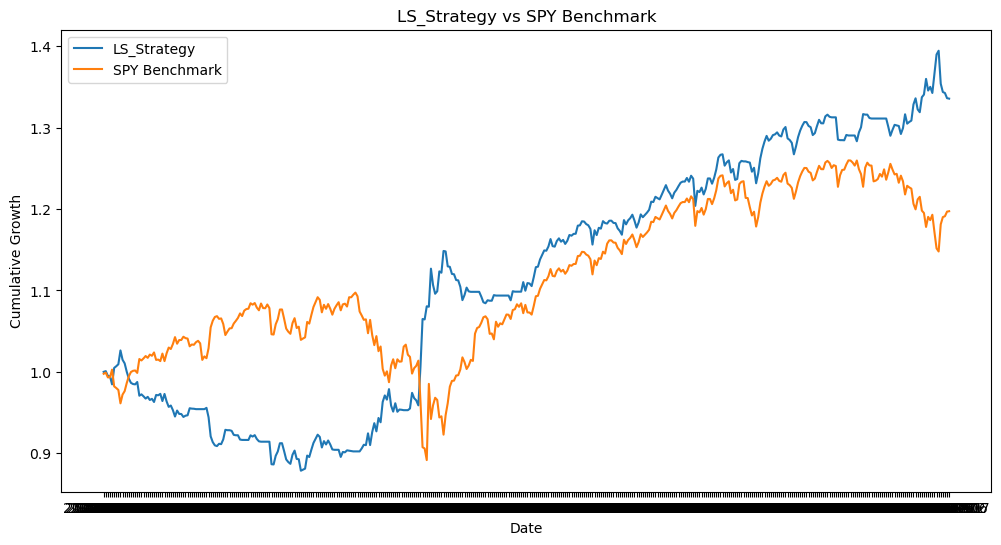

In [123]:
## 14. Visualize cumulative performance
plt.figure(figsize=(12, 6))
plt.plot(cum_LS_strategy, label="LS_Strategy")
plt.plot(cum_benchmark, label="SPY Benchmark")
plt.legend()
plt.title("LS_Strategy vs SPY Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.show()

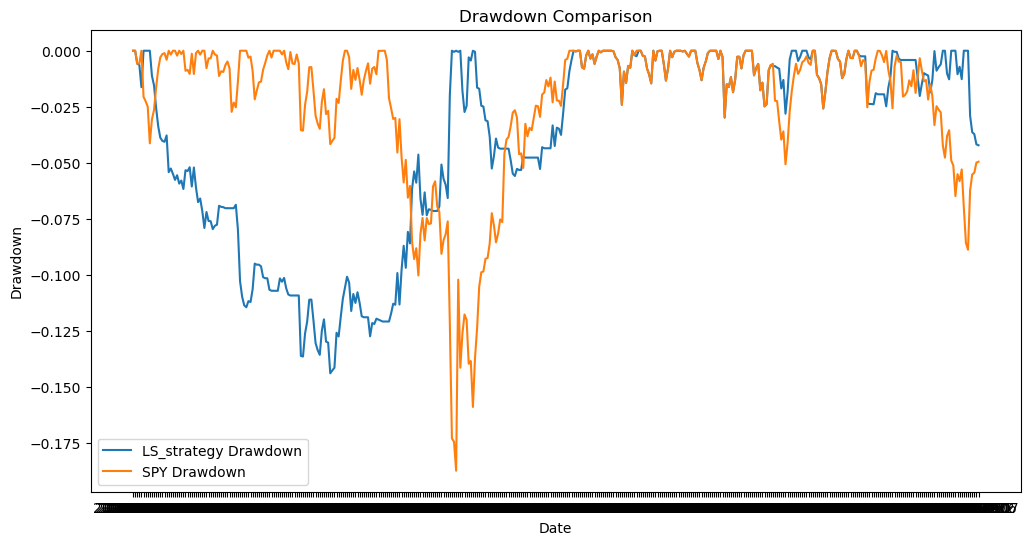

In [124]:
## 15. Visualize drawdown
LS_strategy_drawdown = (cum_LS_strategy - cum_LS_strategy.cummax()) / cum_LS_strategy.cummax()
benchmark_drawdown = (cum_benchmark - cum_benchmark.cummax()) / cum_benchmark.cummax()
plt.figure(figsize=(12, 6))
plt.plot(LS_strategy_drawdown, label="LS_strategy Drawdown")
plt.plot(benchmark_drawdown, label="SPY Drawdown")
plt.legend()
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

In [125]:
## 16. Conclusion:

# In this notebook, I extended the strategy from a long-only filter to a long-short framework using the same model and feature set. By acting on both high and low probability signals, the strategy was able to better capture directional movements and improve overall performance.
# After incorporating realistic transaction costs, the strategy remained profitable and outperformed the SPY benchmark, indicating that the signal contains meaningful predictive power.
# However, the results also reveal key weaknesses: relatively high turnover, sensitivity to transaction costs, and a moderate hit rate below 50%, which suggests reliance on payoff asymmetry rather than consistent accuracy.
# These limitations indicate that execution efficiency and robustness are not yet fully addressed.
# In the next notebook, I will focus on walk-forward validation, threshold sensitivity, and turnover reduction to test whether the strategy’s performance is stable and generalizable.

In [129]:
project_root = Path.cwd().parent
nb06_path = project_root / "data" / "processed" / "notebook_06_model_eval"
nb06_path.mkdir(parents=True, exist_ok=True)
LS_strategy_net_returns.to_csv(nb06_path / "ls_strategy_net_returns.csv", index=True)
cum_LS_strategy.to_csv(nb06_path / "cum_ls_strategy_returns.csv", index=True)
results = pd.DataFrame({
    "probability": pd.Series(y_prob, index=spy_test_returns.index),
    "signal": pd.Series(signal, index=spy_test_returns.index),
    "target_position": pd.Series(target_position, index=spy_test_returns.index),
    "executed_position": pd.Series(executed_position, index=spy_test_returns.index),
    "spy_returns": pd.Series(spy_test_returns, index=spy_test_returns.index),
    "strategy_returns": pd.Series(LS_strategy_net_returns, index=spy_test_returns.index),
    "cum_strategy": pd.Series(cum_LS_strategy, index=spy_test_returns.index),
    "cum_spy": pd.Series(cum_benchmark, index=spy_test_returns.index)})
results = results.sort_index().dropna()
results.to_csv(nb06_path / "ls_strategy_results.csv", index=True)